# 01 — Investment universe and data

**Workstream A** of the group project plan. This notebook is the front of the pipeline: it fixes the
universe, downloads the prices, builds the aligned panel and the return frames, and produces the three
tables and two figures that report section 2 (*Data*) is anchored on.

| Task | Output |
| --- | --- |
| A1 | `UNIVERSE` / `BENCHMARKS` — the single source of truth, imported by every later notebook |
| A2 | Raw price frame, extraction date recorded |
| A3 | Aligned adjusted-close panel on the NYSE calendar |
| A4 | **Table 1.1 — Data availability** |
| A5 | **Table 1.2 — Data quality**, plus the extreme-move screen (Table A1.1) |
| A5b | **Table 1.3 — Dividend and adjustment effect**, plus the corporate-action log (Table A1.2) |
| A6 | Six return frames (daily/weekly/monthly × log/simple) |
| A7 | **Figure 1.1 — Asset correlation heatmap** |
| A8 | **Figure 1.2 — Cumulative growth of $1** |

Conventions come from [`docs/project-definitions.md`](../docs/project-definitions.md). Nothing is
written to disk — prices are pulled from Yahoo Finance on every run, so the extraction date printed in
A2 is the date that must be quoted throughout the report.

**Nothing below names an asset.** Every cell reads the universe from `src/config.py`, and every number
quoted in the markdown is printed by the cell above it, so a change of universe means re-running this
notebook and re-reading the commentary, not editing code.

## Setup

In [1]:
import sys
from pathlib import Path

# The shared modules live at the repository root, one level above this notebook.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config as cfg
from src import data, fmt, viz

viz.use_house_style()
np.random.seed(cfg.SEED)  # nothing here is random, but the seed is fixed everywhere

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

---

## A1 — The investable universe

Twenty-five assets in five sector groups of five, all quoted in USD on US venues, so the pipeline needs
no currency conversion. Strategies allocate **only** to these. The S&P 500 is held outside the universe
as an external reference and is never allocated to.

`UNIVERSE` and `BENCHMARKS` are defined once, in `src/config.py`. Each universe entry carries its own
sector, labels and transaction cost, so adding or swapping an asset is a one-entry edit there — the
asset order, the sector groups, the colours and the cost table are all derived from it.

The sector groups are the group's own, not a GICS classification: `AMZN` sits in *Technology* although
GICS files it under consumer discretionary, and `XOM`, a common stock, sits with the four ETFs in *Real
assets & defensive* as the energy exposure.

In [2]:
universe = pd.DataFrame(cfg.UNIVERSE).T.rename_axis("Ticker")
display(universe[["name", "sector", "asset_class", "instrument", "cost_bp"]].rename(
    columns={"name": "Name", "sector": "Sector", "asset_class": "Asset class",
             "instrument": "Instrument", "cost_bp": "Cost (bp, one-way)"}
))

print(f"{len(cfg.ASSET_ORDER)} assets in {len(cfg.SECTOR_ORDER)} sectors:")
for sector, tickers in cfg.SECTOR_ASSETS.items():
    print(f"  {sector:<25} {', '.join(tickers)}")
print("Stylised facts on:  ", cfg.STYLISED_FACTS_TICKER)
print("Calendar defined by:", cfg.CALENDAR_TICKER)
print("Risk-free series:   ", cfg.RISK_FREE_TICKER)

,Name,Sector,Asset class,Instrument,"Cost (bp, one-way)"
Ticker,,,,,
AAPL,Apple,Technology,Equity -- technology hardware,Common stock,3.0
MSFT,Microsoft,Technology,Equity -- software,Common stock,3.0
ORCL,Oracle,Technology,Equity -- software,Common stock,3.0
AMZN,Amazon.com,Technology,Equity -- internet retail and cloud,Common stock,3.0
INTC,Intel,Technology,Equity -- semiconductors,Common stock,3.0
JNJ,Johnson & Johnson,Healthcare,Equity -- pharmaceuticals,Common stock,3.0
PFE,Pfizer,Healthcare,Equity -- pharmaceuticals,Common stock,3.0
MRK,Merck & Co.,Healthcare,Equity -- pharmaceuticals,Common stock,3.0
UNH,UnitedHealth Group,Healthcare,Equity -- managed care,Common stock,3.0


25 assets in 5 sectors:
  Technology                AAPL, MSFT, ORCL, AMZN, INTC
  Healthcare                JNJ, PFE, MRK, UNH, ABT
  Financials                JPM, BAC, WFC, GS, AXP
  Consumer staples          PG, KO, PEP, WMT, CL
  Real assets & defensive   GLD, SLV, TLT, VNQ, XOM
Stylised facts on:   JPM
Calendar defined by: SPY
Risk-free series:    ^IRX


In [3]:
# Proxy labels, carried on the universe itself so they cannot be forgotten in
# the prose. A proxy is a series that is not itself a holding.
proxies = {ticker: info["proxy_for"] for ticker, info in cfg.UNIVERSE.items() if info["proxy_for"]}
if proxies:
    for ticker, label in proxies.items():
        print(f"PROXY  {ticker}: {label}")
else:
    print("No proxies: every asset in the universe is a directly investable listed security.")

display(pd.DataFrame(cfg.BENCHMARKS).T.rename_axis("Ticker").rename(
    columns={"name": "Name", "investable": "Investable", "use": "Use"}
))

No proxies: every asset in the universe is a directly investable listed security.


,Name,Investable,Use
Ticker,,,
^GSPC,S&P 500 price index,False,Quoted when describing 'the market'; excludes ...
SPY,SPDR S&P 500 ETF Trust,True,Every performance comparison; also defines the...


---

## A2 — Download and extraction date

Full available history for the universe, both benchmarks and the risk-free series, in one call.
`auto_adjust=True`, so prices are adjusted for splits, spin-offs and distributions (A5b measures what
that is worth).

**The extraction date printed below must be quoted identically in every table and figure in the
report** (plan G2).

In [4]:
close, volume, extraction_date = data.download_raw()

print(f"Extraction date : {extraction_date.isoformat()}")
print(f"Source          : Yahoo Finance via yfinance, auto_adjust=True")
print(f"Tickers         : {', '.join(cfg.ALL_TICKERS)}")
print(f"Raw frame       : {close.shape[0]:,} dates x {close.shape[1]} tickers")
print(f"Earliest obs.   : {close.dropna(how='all').index[0].date()}")
print(f"Latest obs.     : {close.dropna(how='all').index[-1].date()}")

Extraction date : 2026-10-07
Source          : Yahoo Finance via yfinance, auto_adjust=True
Tickers         : AAPL, MSFT, ORCL, AMZN, INTC, JNJ, PFE, MRK, UNH, ABT, JPM, BAC, WFC, GS, AXP, PG, KO, PEP, WMT, CL, GLD, SLV, TLT, VNQ, XOM, ^GSPC, SPY, ^IRX
Raw frame       : 24,808 dates x 28 tickers
Earliest obs.   : 1927-12-30
Latest obs.     : 2026-10-06


---

## A3 — Calendar and alignment

The trading calendar is the set of dates `SPY` trades, and every series is reindexed onto it. Any
observation that falls outside NYSE sessions — a weekend print from something that trades every day —
is discarded rather than aggregated into the adjacent session, and counted below.

Three rules, all from definitions §4:

- **Staggered entry.** Assets enter on their own first observation. Pre-entry cells stay `NaN` — never
  zero-filled, never back-filled.
- **Interior gaps** are forward-filled up to 3 sessions. Anything longer is reported, not patched.
- **Nothing is filled silently.** Every fill is counted and shown in Table 1.2.

In [5]:
panel = data.build_panel(close, volume, extraction_date, start=cfg.PANEL_START)
span = (panel.calendar[-1] - panel.calendar[0]).days / 365.25
intersection = (panel.calendar[-1] - panel.full_panel_start).days / 365.25

print(f"Panel period       : {panel.calendar[0].date()} to {panel.calendar[-1].date()}")
print(f"NYSE sessions      : {len(panel.calendar):,}")
print(f"Span               : {span:.1f} years")
print(f"All-asset intersection starts: {panel.full_panel_start.date()}  ({intersection:.1f} years)")

latest_entry = max(cfg.ASSET_ORDER, key=lambda t: close[t].first_valid_index())
print(f"Latest-listed asset: {latest_entry}, first observation {close[latest_entry].first_valid_index().date()}"
      " -- the earliest date the panel could start with every asset present")
print()

def report(label, counts):
    nonzero = {t: n for t, n in counts.items() if n}
    print(f"{label}: " + (", ".join(f"{t} {n:,}" for t, n in nonzero.items()) if nonzero else "none"))

report("Observations dropped as off-calendar", panel.dropped_offcalendar)
report(f"Sessions forward-filled (interior gaps, limit {cfg.FFILL_LIMIT})", panel.fills)

if panel.unpatched_gaps.empty:
    print("Gaps longer than the fill limit: none.")
else:
    display(panel.unpatched_gaps)

Panel period       : 2011-10-03 to 2026-10-06
NYSE sessions      : 3,774
Span               : 15.0 years
All-asset intersection starts: 2011-10-03  (15.0 years)
Latest-listed asset: SLV, first observation 2006-04-28 -- the earliest date the panel could start with every asset present

Observations dropped as off-calendar: none
Sessions forward-filled (interior gaps, limit 3): none
Gaps longer than the fill limit: none.


The panel spans **15.0 years**, as the brief requires, and **every asset is present on its first
session**: the intersection is the whole panel. The latest-listed asset, `SLV`, has data from April
2006 — five years before the panel opens — so the brief's 15-year minimum binds on the panel, not on
any asset. Nothing trades off the NYSE calendar and nothing needed filling.

The staggered-entry and gap rules stay in the code because they are the right rules, not because this
universe exercises them: a future universe with a short-history or 24/7 asset would go through the same
path and the counts above would stop being zero.

---

## A4 — Table 1.1, data availability

History per asset, measured over each asset's **own full history** rather than the panel, because the
question this table answers is whether the asset clears the brief's 15-year minimum.

Liquidity is measured differently: **median daily dollar volume over the panel**, because the question
there is whether the asset was tradable in the period the backtest uses. Dollars, unlike share counts,
compare across rows. It is adjusted close × volume, so it slightly understates early-panel turnover for
assets that pay distributions.

In [6]:
availability = data.availability_table(panel, cfg.ASSET_ORDER + [cfg.PERFORMANCE_BENCHMARK, "^GSPC"])

table_1_1 = fmt.style(availability, {
    "Years": lambda v: fmt.number(v, 1),
    "Obs./yr": lambda v: fmt.count(v),
    "Median $ volume (m)": fmt.count,
})
# An index level's "volume" is the summed volume of its constituents, not a
# tradable quantity -- not applicable, so an em dash.
table_1_1.loc["^GSPC", "Median $ volume (m)"] = fmt.NA

print("Table 1.1 - Data availability. Yahoo Finance, extracted "
      f"{panel.extraction_date.isoformat()}. History over each asset's full record; median dollar volume "
      f"over the panel period {panel.calendar[0].date()} to {panel.calendar[-1].date()}, USD millions.")
display(table_1_1)

Table 1.1 - Data availability. Yahoo Finance, extracted 2026-10-07. History over each asset's full record; median dollar volume over the panel period 2011-10-03 to 2026-10-06, USD millions.


,Name,Sector,Asset class,Instrument,First obs.,Years,Obs./yr,Median $ volume (m),Meets 15y
Ticker,,,,,,,,,
AAPL,Apple,Technology,Equity -- technology hardware,Common stock,1980-12-12,45.8,252,"7,856",Yes
MSFT,Microsoft,Technology,Equity -- software,Common stock,1986-03-13,40.6,252,"3,123",Yes
ORCL,Oracle,Technology,Equity -- software,Common stock,1986-03-12,40.6,252,613,Yes
AMZN,Amazon.com,Technology,Equity -- internet retail and cloud,Common stock,1997-05-15,29.4,252,"5,722",Yes
INTC,Intel,Technology,Equity -- semiconductors,Common stock,1980-03-17,46.6,252,993,Yes
JNJ,Johnson & Johnson,Healthcare,Equity -- pharmaceuticals,Common stock,1962-01-02,64.8,252,752,Yes
PFE,Pfizer,Healthcare,Equity -- pharmaceuticals,Common stock,1972-06-01,54.3,252,627,Yes
MRK,Merck & Co.,Healthcare,Equity -- pharmaceuticals,Common stock,1962-01-02,64.8,252,562,Yes
UNH,UnitedHealth Group,Healthcare,Equity -- managed care,Common stock,1984-10-17,42.0,252,730,Yes


In [7]:
assets = availability.loc[cfg.ASSET_ORDER]
short = assets.query(f"Years < {cfg.MIN_YEARS_REQUIRED}")
print(f"Assets short of the {cfg.MIN_YEARS_REQUIRED}-year minimum: {len(short)} of {len(cfg.ASSET_ORDER)}")
for ticker, row in short.iterrows():
    print(f"  {ticker:<8} {row['Years']:.1f} years (from {row['First obs.']})")
print(f"Shortest history: {assets['Years'].idxmin()} at {assets['Years'].min():.1f} years")

liquidity = assets["Median $ volume (m)"]
print(f"Median $ volume: {liquidity.idxmin()} lowest at ${liquidity.min():,.0f}m/day, "
      f"{liquidity.idxmax()} highest at ${liquidity.max():,.0f}m/day")

Assets short of the 15-year minimum: 0 of 25
Shortest history: SLV at 20.4 years
Median $ volume: CL lowest at $220m/day, AAPL highest at $7,856m/day


---

## A5 — Table 1.2, data quality

Missing and stale observations within the panel. `% zero-return days` is the staleness test: a price
that does not move is either a genuinely flat session or a price that was not refreshed, and a thinly
traded name produces many of the second kind. It is measured on the **final, filled** series, so any
forward-filled session appears here as a zero return — the honest reading, since it is the filled
series the analysis consumes.

`Days |r| > 15%` is the screen for a corporate action the adjustment missed: an unadjusted split or
spin-off shows up as a one-day crash. Every flagged session is listed and checked in Table A1.1 below.

In [8]:
quality = data.quality_table(panel, cfg.ASSET_ORDER + [cfg.PERFORMANCE_BENCHMARK])
extreme_col = f"Days |r| > {cfg.EXTREME_MOVE:.0%}"

table_1_2 = fmt.style(quality, {
    "Obs.": fmt.count,
    "Missing obs.": fmt.count,
    "Longest gap (sessions)": fmt.count,
    "% zero-return days": lambda v: fmt.percent(v, 2),
    extreme_col: fmt.count,
})

print("Table 1.2 - Data quality. Panel period "
      f"{panel.calendar[0].date()} to {panel.calendar[-1].date()}, NYSE sessions. "
      "Zero-return share measured after the forward-fill.")
display(table_1_2)

Table 1.2 - Data quality. Panel period 2011-10-03 to 2026-10-06, NYSE sessions. Zero-return share measured after the forward-fill.


,Panel start,Obs.,Missing obs.,Longest gap (sessions),% zero-return days,Days |r| > 15%,Treatment applied
Ticker,,,,,,,
AAPL,2011-10-03,"3,774",0,0,0.19,0,None required
MSFT,2011-10-03,"3,774",0,0,0.64,1,None required
ORCL,2011-10-03,"3,774",0,0,0.77,2,None required
AMZN,2011-10-03,"3,774",0,0,0.16,1,None required
INTC,2011-10-03,"3,774",0,0,0.90,8,None required
JNJ,2011-10-03,"3,774",0,0,0.50,0,None required
PFE,2011-10-03,"3,774",0,0,1.40,0,None required
MRK,2011-10-03,"3,774",0,0,0.74,0,None required
UNH,2011-10-03,"3,774",0,0,0.32,4,None required


In [9]:
# Reconciliation: Table 1.2's observation count must equal the sessions available
# to each asset since its entry, minus anything the fill limit could not reach.
for ticker in cfg.ASSET_ORDER:
    first = panel.prices_raw[ticker].first_valid_index()
    available = int((panel.calendar >= first).sum())
    reported = int(quality.loc[ticker, "Obs."])
    unfilled = int(quality.loc[ticker, "Missing obs."]) - panel.fills[ticker]
    assert reported == available - unfilled, ticker
    assert reported == int(panel.prices[ticker].notna().sum()), ticker
print(f"Table 1.1 and 1.2 reconcile with the panel for all {len(cfg.ASSET_ORDER)} assets.")

zero = quality.loc[cfg.ASSET_ORDER, "% zero-return days"]
print(f"Zero-return share: {zero.min():.2f}% ({zero.idxmin()}) to {zero.max():.2f}% ({zero.idxmax()})")

Table 1.1 and 1.2 reconcile with the panel for all 25 assets.
Zero-return share: 0.08% (GS) to 1.91% (SLV)


**No staleness problem.** The highest zero-return share in the universe is under 2%, the level of a
liquid instrument that occasionally closes unchanged, not of a stale quote. Every asset trades at least
a few hundred million dollars a day (Table 1.1). The thin-trading bias — stale prices that pull measured
volatility down and correlations toward zero, flattering inverse-volatility and minimum-variance
weights — is therefore absent from this universe, and the staleness screen stays in Table 1.2 to show
that rather than assume it.

### Table A1.1 — Extreme daily moves

Every session on which an asset moved more than 15% in log terms, with how many assets did so the same
day. A move shared with many others is a market event. A lone move is either company news or a data
fault, and a data fault would coincide with a corporate-action date (Table A1.2).

In [10]:
moves = data.extreme_moves(panel)
print(f"Table A1.1 - Daily log returns beyond {cfg.EXTREME_MOVE:.0%}. "
      f"Panel period {panel.calendar[0].date()} to {panel.calendar[-1].date()}, n = {len(moves)} asset-sessions.")
display(fmt.style(moves.set_index(["Date", "Ticker"]), {
    "Log return %": lambda v: fmt.percent(v, 1),
    "Assets past threshold that day": fmt.count,
}))

by_year = moves["Date"].str[:4].value_counts().sort_index()
print("By year:", ", ".join(f"{y} {n}" for y, n in by_year.items()))
print("By asset:", ", ".join(f"{t} {n}" for t, n in moves["Ticker"].value_counts().items()))
shared = moves[moves["Assets past threshold that day"] > 1]
print(f"Shared with another asset the same day: {len(shared)} of {len(moves)}, "
      f"on {shared['Date'].nunique()} sessions ({', '.join(sorted(shared['Date'].unique()))})")

Table A1.1 - Daily log returns beyond 15%. Panel period 2011-10-03 to 2026-10-06, n = 32 asset-sessions.


Log return % Assets past threshold that day
Date       Ticker                                            
2020-03-09 BAC           -15.9                              1
2020-03-12 WFC           -17.3                              1
2020-03-13 ORCL           18.6                              6
           INTC           17.8                              6
           JPM            16.6                              6
           BAC            16.4                              6
           GS             16.2                              6
           AXP            17.6                              6
2020-03-16 MSFT          -15.9                              7
           INTC          -19.9                              7
           UNH           -19.0                              7
           JPM           -16.2                              7
           BAC           -16.7                              7
           WFC           -15.3                              7
           VNQ           -19.5                              7
2020-03-18 AXP           -16.0                              1
2020-03-24 BAC            15.1                              2
           AXP            19.8                              2
2020-07-24 INTC          -17.7                              1
2020-11-09 AXP            19.4                              1
2022-04-29 AMZN          -15.1                              1
2024-08-02 INTC          -30.2                              1
2025-04-09 INTC           17.2                              1
2025-04-17 UNH           -25.3                              1
2025-05-13 UNH           -19.6                              1
2025-09-10 ORCL           30.7                              1
2025-09-18 INTC           20.5                              1
2026-01-23 INTC          -18.7                              1
2026-01-27 UNH           -21.8                              1
2026-01-30 SLV           -33.6                              1
2026-02-05 SLV           -17.2                              1
2026-04-24 INTC           21.2                              1

By year: 2020 20, 2022 1, 2024 1, 2025 5, 2026 5
By asset: INTC 8, BAC 4, AXP 4, UNH 4, WFC 2, ORCL 2, JPM 2, SLV 2, GS 1, MSFT 1, VNQ 1, AMZN 1
Shared with another asset the same day: 15 of 32, on 3 sessions (2020-03-13, 2020-03-16, 2020-03-24)


The flagged moves are **real**: they fall either in the COVID crash of March 2020, when up to seven
assets moved more than 15% on the same day, or on single-name news — earnings and guidance shocks at
`INTC` and `UNH`, `ORCL`'s jump in September 2025, and a 34% one-day fall in `SLV` on 30 January
2026, two days after the top of a rally that had nearly quadrupled it in a year. None falls on a corporate-action date (checked
in A5b), so none is an adjustment artefact. They stay in the data: they are exactly the fat tails the
stylised facts section measures and the drawdowns the backtest has to survive.

---

## A5b — Table 1.3, dividends, corporate actions and the index/tracker split

Every series in the panel is an **adjusted close**: Yahoo restates past prices for later splits,
spin-offs and distributions, which is equivalent to reinvesting each distribution on its ex-date. That
one switch is the whole of the pipeline's dividend treatment, so this table shows what it is worth, by
re-downloading the **price-only** series (`auto_adjust=False` — still split- and spin-off-adjusted, but
not adjusted for cash distributions) and comparing the two on the same dates.

- **Distributions pp/yr** is total return minus price return: what an investor received in cash income.
- **Split / spin-off events** counts the split-type adjustments Yahoo applied — listed and classified
  in Table A1.2.
- **`^GSPC` against `SPY`** is the index/tracker distinction in one row pair. The index is a price
  index, so its two columns are identical; the ETF that tracks it earns the dividends, less its fee.

In [11]:
close_unadjusted, dividends, splits = data.download_unadjusted()
adjustment = data.adjustment_table(panel, close_unadjusted, dividends, splits)

table_1_3 = fmt.style(adjustment, {
    "Total return %/yr": lambda v: fmt.percent(v, 1),
    "Price return %/yr": lambda v: fmt.percent(v, 1),
    "Distributions pp/yr": lambda v: fmt.number(v, 1),
    "Distribution events": fmt.count,
    "Split / spin-off events": fmt.count,
})

print("Table 1.3 - Dividend and adjustment effect. Yahoo Finance, extracted "
      f"{panel.extraction_date.isoformat()}. Annualised over each asset's span within the panel, "
      f"to {panel.calendar[-1].date()}. Total return from adjusted closes; price return from closes "
      "adjusted for splits and spin-offs only.")
display(table_1_3)

Table 1.3 - Dividend and adjustment effect. Yahoo Finance, extracted 2026-10-07. Annualised over each asset's span within the panel, to 2026-10-06. Total return from adjusted closes; price return from closes adjusted for splits and spin-offs only.


,Instrument,From,Total return %/yr,Price return %/yr,Distributions pp/yr,Distribution events,Split / spin-off events
Ticker,,,,,,,
AAPL,Common stock,2011-10-03,25.4,23.9,1.5,57,2
MSFT,Common stock,2011-10-03,24.8,22.7,2.1,60,0
ORCL,Common stock,2011-10-03,13.2,11.6,1.6,59,0
AMZN,Common stock,2011-10-03,23.6,23.6,0.0,0,1
INTC,Common stock,2011-10-03,14.8,12.0,2.9,52,0
JNJ,Common stock,2011-10-03,13.0,9.9,3.2,60,0
PFE,Common stock,2011-10-03,7.9,3.5,4.4,60,1
MRK,Common stock,2011-10-03,14.5,10.9,3.6,60,1
UNH,Common stock,2011-10-03,17.5,15.6,1.9,60,0


In [12]:
# The checks the prose relies on.
# 1. A price index pays nothing: adjusted and price-only returns coincide for ^GSPC.
assert abs(adjustment.loc["^GSPC", "Distributions pp/yr"]) < 0.05

gap = adjustment.loc["SPY", "Total return %/yr"] - adjustment.loc["^GSPC", "Total return %/yr"]
print(f"SPY total return minus ^GSPC price return: {gap:.1f} pp/yr "
      "(the dividend yield, net of SPY's expense ratio)")

income = adjustment.loc[cfg.ASSET_ORDER, "Distributions pp/yr"].sort_values(ascending=False)
print("Largest distribution contribution: " + ", ".join(f"{t} {v:.1f}" for t, v in income.head(5).items()))
print("Pay nothing: " + (", ".join(income[income.abs() < 0.05].index) or "none"))

negative_price = adjustment.loc[cfg.ASSET_ORDER].query("`Price return %/yr` < 0")
for ticker, row in negative_price.iterrows():
    print(f"Negative on price alone: {ticker} {row['Price return %/yr']:.1f}%/yr price, "
          f"{row['Total return %/yr']:.1f}%/yr total")

SPY total return minus ^GSPC price return: 2.0 pp/yr (the dividend yield, net of SPY's expense ratio)
Largest distribution contribution: PFE 4.4, VNQ 4.2, XOM 4.1, MRK 3.6, KO 3.3
Pay nothing: AMZN, GLD, SLV
Negative on price alone: TLT -3.1%/yr price, -0.3%/yr total


Distributions are **material almost everywhere**. Every stock except `AMZN` pays a regular dividend,
worth roughly 1.5–4.5 points a year, and for the defensive end of the universe they are most of the
return: about half of `VNQ`'s, over 40% of `XOM`'s, about a third of the consumer-staples names', and **all**
of `TLT`'s and more — on price alone the long Treasury fund lost about 3% a year, and income brings
it only back to roughly zero. A strategy scored on unadjusted prices would be penalised for holding
exactly the income assets. `GLD`, `SLV` and `AMZN` pay nothing, and adjustment leaves them unchanged.

Every asset is a US-domiciled security held by a US investor, so there is no foreign withholding tax to
net off and no currency layer inside any return. The one gap the adjustment leaves is that Yahoo
reinvests the **gross** dividend, with no allowance for US tax — the same for every asset, and the same
for the `SPY` benchmark.

### Table A1.2 — Corporate-action log

Yahoo books a **spin-off as a fractional "split"**: the ratio is the parent's pre-spin price over its
post-spin price, so the adjusted series continues as if the spun-off shares had been sold on the
ex-date and the proceeds reinvested in the parent. A whole-number ratio is a genuine split. The log return on each
event date is shown: an adjustment that failed would show up as a crash of roughly the size of the
ratio.

In [13]:
actions = data.corporate_actions(panel, splits)
print("Table A1.2 - Split-type adjustments within the panel. Yahoo Finance, extracted "
      f"{panel.extraction_date.isoformat()}. n = {len(actions)}.")
display(fmt.style(actions.set_index(["Date", "Ticker"]), {
    "Ratio": lambda v: fmt.number(v, 3),
    "Adjusted log return % that day": lambda v: fmt.percent(v, 2),
}))

# Each event-day return must be an ordinary-sized move for that asset, not a
# crash: inside three of its own daily standard deviations.
daily_log = np.log(panel.prices[cfg.ASSET_ORDER]).diff()
for _, event in actions.iterrows():
    sd = daily_log[event["Ticker"]].std() * 100
    assert abs(event["Adjusted log return % that day"]) < 3 * sd, (event["Ticker"], event["Date"])

# And no extreme move (Table A1.1) falls on a corporate-action date.
event_keys = set(zip(actions["Date"], actions["Ticker"]))
assert not event_keys & set(zip(moves["Date"], moves["Ticker"]))

counts = actions["Type"].value_counts()
print(", ".join(f"{n} {kind.lower()}" for kind, n in counts.items()) +
      "; every event-day return inside 3 SD of the asset's own daily moves, none in Table A1.1.")

Table A1.2 - Split-type adjustments within the panel. Yahoo Finance, extracted 2026-10-07. n = 9.


,,Ratio,Type,Adjusted log return % that day
Date,Ticker,,,
2012-08-13,KO,2.000,Split,-0.24
2013-01-02,ABT,2.084,Spin-off (price factor),1.96
2013-05-16,CL,2.000,Split,0.17
2014-06-09,AAPL,7.000,Split,1.59
2020-08-31,AAPL,4.000,Split,3.33
2020-11-17,PFE,1.054,Spin-off (price factor),1.74
2021-06-03,MRK,1.048,Spin-off (price factor),2.07
2022-06-06,AMZN,20.000,Split,1.97
2024-02-26,WMT,3.000,Split,1.83


6 split, 3 spin-off (price factor); every event-day return inside 3 SD of the asset's own daily moves, none in Table A1.1.


Nine events, all clean. Six are ordinary splits (`AAPL` twice, `AMZN`, `WMT`, `KO`, `CL`). Three are
**spin-offs** that Yahoo absorbs as fractional ratios — `ABT` (AbbVie, January 2013), `PFE` (Upjohn into
Viatris, November 2020) and `MRK` (Organon, June 2021) — and on each event date the adjusted return is
an ordinary-sized move of about 2%, not the double-digit drop an unadjusted spin-off would leave.

The adjustment treats a spin-off as if the spun-off shares were sold on the ex-date and reinvested in
the parent. That is the standard total-return convention, and the only way to keep a single-ticker history
continuous; an investor who kept the spun-off shares would have earned a different return.

---

## A6 — Return frames

Six frames: daily, weekly and monthly, each in log and simple returns.

- **Log returns** — `ln(P_t) − ln(P_{t−1})` — for all stylised-facts analysis, because they aggregate by
  addition across time.
- **Simple returns** — for all portfolio compounding and performance statistics, because they aggregate
  by addition across *assets*, which is what a portfolio weight does.

Weekly and monthly log returns are the sum of the daily log returns in the period; the simple frames are
the equivalent compounded figure, `exp(sum) − 1`, so both kinds describe the same price moves. Weeks end
Friday, months on the last trading day. Periods before an asset's entry stay `NaN` rather than summing
to zero.

In [14]:
returns = data.build_returns(panel)

summary = pd.DataFrame(
    [
        {
            "Frequency": frequency,
            "Kind": kind,
            "Periods": len(returns[(frequency, kind)]),
            "Complete rows (all assets)": int(returns[(frequency, kind)][cfg.ASSET_ORDER].dropna().shape[0]),
            "First": returns[(frequency, kind)].dropna(how="all").index[0].date(),
            "Last": returns[(frequency, kind)].dropna(how="all").index[-1].date(),
        }
        for frequency in cfg.FREQUENCY_ORDER
        for kind in ("log", "simple")
    ]
)
display(summary.set_index(["Frequency", "Kind"]))

Periods  Complete rows (all assets)       First        Last
Frequency Kind                                                               
daily     log        3773                        3773  2011-10-04  2026-10-06
          simple     3773                        3773  2011-10-04  2026-10-06
weekly    log         784                         784  2011-10-07  2026-10-09
          simple      784                         784  2011-10-07  2026-10-09
monthly   log         181                         181  2011-10-31  2026-10-31
          simple      181                         181  2011-10-31  2026-10-31

In [15]:
# Check the two kinds agree: exp(log) - 1 == simple, to numerical precision.
for frequency in cfg.FREQUENCY_ORDER:
    log_returns = returns[(frequency, "log")]
    simple = returns[(frequency, "simple")]
    assert np.allclose(np.expm1(log_returns), simple, equal_nan=True), frequency

# Check weekly and monthly log returns really are sums of the daily ones.
daily_log = returns[("daily", "log")]
for frequency, rule in (("weekly", "W-FRI"), ("monthly", "ME")):
    rebuilt = daily_log.resample(rule).sum(min_count=1)
    assert np.allclose(rebuilt, returns[(frequency, "log")], equal_nan=True), frequency

print("Return frames consistent across frequency and kind.")

Return frames consistent across frequency and kind.


---

## A7 — Figure 1.1, asset correlation heatmap

Daily log-return correlations over the **full-panel period** — from the first date every asset has data
— so every pair is measured on the same sample and the matrix is directly comparable cell to cell.
Assets are in the fixed sector order, with a gap between sector blocks so the block structure reads at
a glance. `SPY` is shown in the last row and column as the external reference.

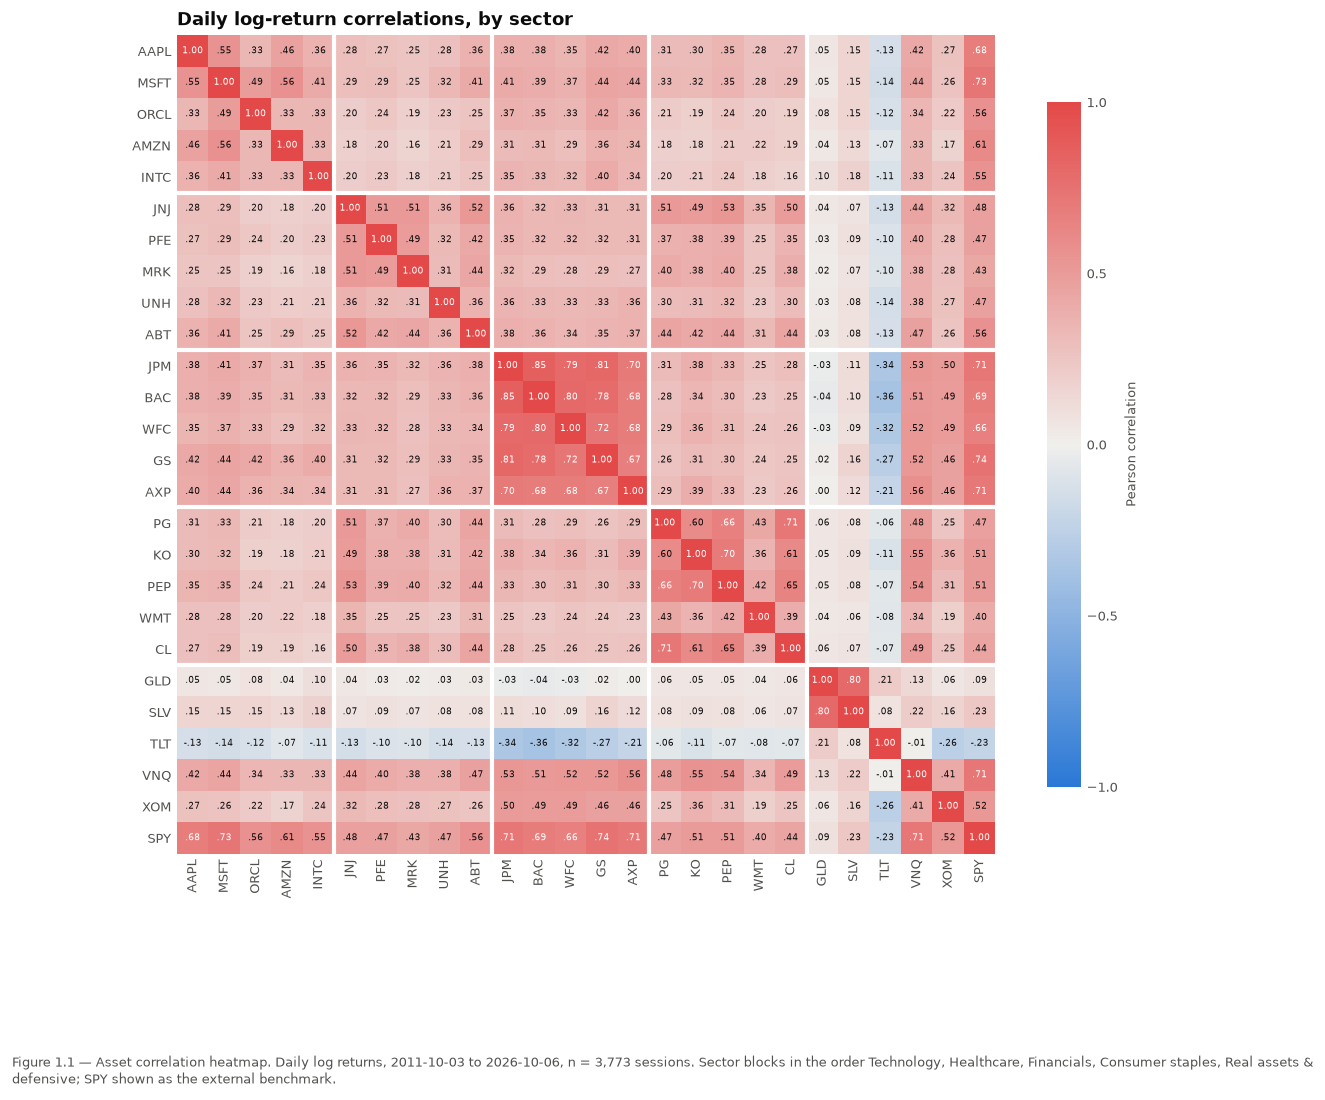

In [16]:
full_panel_returns = returns[("daily", "log")].loc[panel.full_panel_start:]
heatmap_order = cfg.ASSET_ORDER + [cfg.PERFORMANCE_BENCHMARK]

fig, ax = plt.subplots(figsize=(11.0, 9.5))
ax, correlations = viz.correlation_heatmap(
    full_panel_returns, heatmap_order, ax=ax, groups=list(cfg.SECTOR_ASSETS.values())
)
ax.set_title("Daily log-return correlations, by sector")
viz.caption(
    ax,
    f"Figure 1.1 — Asset correlation heatmap. Daily log returns, "
    f"{panel.full_panel_start.date()} to {panel.calendar[-1].date()}, "
    f"n = {len(full_panel_returns.dropna()):,} sessions. Sector blocks in the order "
    f"{', '.join(cfg.SECTOR_ORDER)}; SPY shown as the external benchmark.",
)
plt.show()

In [17]:
A = cfg.ASSET_ORDER
off_diagonal = correlations.loc[A, A].where(~np.eye(len(A), dtype=bool)).stack().dropna()
sector_of = {t: cfg.UNIVERSE[t]["sector"] for t in A}
same_sector = pd.Series([sector_of[a] == sector_of[b] for a, b in off_diagonal.index], index=off_diagonal.index)

print(f"Mean pairwise correlation, all {len(A)} assets: {off_diagonal.mean():.2f}")
print(f"  within a sector : {off_diagonal[same_sector].mean():.2f}")
print(f"  across sectors  : {off_diagonal[~same_sector].mean():.2f}")
print(f"Highest pair: {off_diagonal.idxmax()} at {off_diagonal.max():.2f}")
print(f"Lowest pair : {off_diagonal.idxmin()} at {off_diagonal.min():.2f}")
print()

rows = []
for sector, block in cfg.SECTOR_ASSETS.items():
    inner = correlations.loc[block, block].where(~np.eye(len(block), dtype=bool)).stack().dropna()
    rows.append({"Sector": sector, "Mean within-sector corr.": inner.mean(),
                 "Mean corr. with SPY": correlations.loc[block, cfg.PERFORMANCE_BENCHMARK].mean()})
display(fmt.style(pd.DataFrame(rows).set_index("Sector"), {
    "Mean within-sector corr.": lambda v: fmt.number(v, 2),
    "Mean corr. with SPY": lambda v: fmt.number(v, 2),
}))

negative = (correlations.loc[A, A] < 0).sum().sort_values(ascending=False)
print("Negatively correlated with how many of the other assets: "
      + ", ".join(f"{t} {n}" for t, n in negative[negative > 0].head(4).items()))

# How much of the cross-section one common factor explains, and how close the
# matrix is to singular -- what an optimiser inverting it will feel.
eigenvalues = np.linalg.eigvalsh(correlations.loc[A, A].to_numpy())
print(f"First principal component: {eigenvalues[-1] / eigenvalues.sum() * 100:.0f}% of total variance "
      f"(a single market factor); smallest eigenvalue {eigenvalues[0]:.2f}, "
      f"condition number {eigenvalues[-1] / eigenvalues[0]:.0f}")

Mean pairwise correlation, all 25 assets: 0.28
  within a sector : 0.46
  across sectors  : 0.25
Highest pair: ('JPM', 'BAC') at 0.85
Lowest pair : ('BAC', 'TLT') at -0.36



,Mean within-sector corr.,Mean corr. with SPY
Sector,,
Technology,0.42,0.62
Healthcare,0.42,0.48
Financials,0.75,0.70
Consumer staples,0.55,0.47
Real assets & defensive,0.18,0.27


Negatively correlated with how many of the other assets: TLT 22, GLD 3, WFC 2, JPM 2
First principal component: 36% of total variance (a single market factor); smallest eigenvalue 0.14, condition number 64


**The universe has structure, and it is sector structure.** Across all 25 the mean pairwise correlation
is about 0.28 — but that average hides two very different regimes. Inside a sector block, names move
together: the **financials correlate at about 0.75** among themselves (`JPM`–`BAC` 0.85, the highest
pair in the matrix), consumer staples at 0.55, technology and healthcare around 0.4. Across sectors the
average falls to about 0.25. A single market factor explains roughly a third of the total variance.

**The diversifiers sit in one block.** `TLT` is negatively correlated with 22 of the other 24 assets,
most strongly with the banks (about −0.35, since falling yields hurt bank margins and lift long bonds)
and with `SPY` (−0.23). `GLD` is essentially uncorrelated with everything except `SLV` (0.80). `VNQ`
and `XOM`, by contrast, behave like equities (0.71 and 0.52 with `SPY`), so the *Real assets &
defensive* group is defensive mostly through `TLT` and `GLD`.

Two consequences for the backtest, to carry into workstreams C–D:

- **Correlation-aware strategies have something to work with.** The contrast between the
  correlation-blind (EW, IV) and correlation-aware (GMV, ERC, MDP, MDC) strategies is largest when a
  drawn subset mixes a sector pair with a diversifier, and smallest when it holds four unrelated stocks.
- **Near-collinear pairs.** A subset that draws two large banks hands the optimiser two assets at
  0.8–0.85 correlation. Their difference is poorly estimated, so unconstrained mean–variance weights
  would swing between them. Long-only constraints contain this, but it is the first place to look if
  MV or MSR turnover comes out high.

---

## A8 — Figure 1.2, cumulative growth of $1

Twenty-five lines on one chart would be unreadable, and the palette has one colour per *sector*, not per
asset. So the figure is a grid of **small multiples**: one panel per asset, one row per sector, every
panel on the **same log y-axis** so heights compare across the whole grid, and `SPY` repeated in each
as the dashed grey reference. Each panel's title names its asset and its terminal value, so identity
never rests on colour.

Every series is rebased to $1 at the first date all assets have data — here, the first session of the
panel.

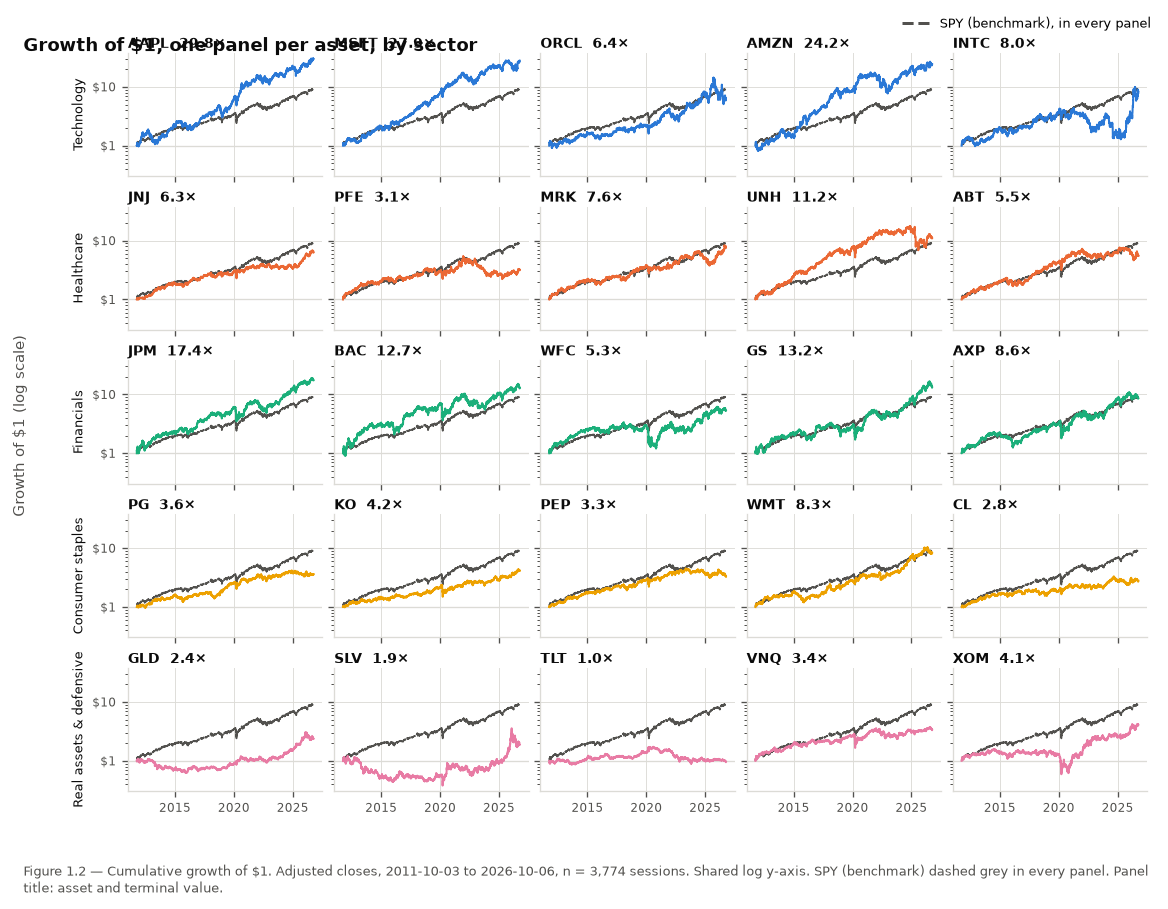

In [18]:
fig, wealth = viz.growth_small_multiples(panel.prices, cfg.SECTOR_ASSETS)
fig.suptitle("Growth of $1, one panel per asset, by sector", x=0.0, ha="left",
             fontsize=11, fontweight="bold", color=cfg.INK_PRIMARY)
viz.caption(
    fig.axes[0],
    f"Figure 1.2 — Cumulative growth of $1. Adjusted closes, "
    f"{wealth.index[0].date()} to {wealth.index[-1].date()}, n = {len(wealth):,} sessions. "
    f"Shared log y-axis. {cfg.PERFORMANCE_BENCHMARK} (benchmark) dashed grey in every panel. "
    "Panel title: asset and terminal value.",
)
plt.show()

In [19]:
terminal = wealth.iloc[-1].rename("Growth of $1").to_frame()
years = (wealth.index[-1] - wealth.index[0]).days / 365.25
terminal["Ann. return %"] = (terminal["Growth of $1"] ** (1 / years) - 1) * 100
terminal["Ann. volatility %"] = (
    np.log(wealth).diff().std() * np.sqrt(cfg.TRADING_DAYS) * 100
)
terminal.insert(0, "Sector", [cfg.UNIVERSE.get(t, {}).get("sector", "Benchmark") for t in terminal.index])

print(f"Buy-and-hold over the panel, {years:.1f} years. "
      "Descriptive only -- not a strategy result.")
display(fmt.style(terminal.loc[cfg.ASSET_ORDER + [cfg.PERFORMANCE_BENCHMARK]], {
    "Growth of $1": lambda v: fmt.number(v, 2),
    "Ann. return %": lambda v: fmt.percent(v, 2),
    "Ann. volatility %": lambda v: fmt.percent(v, 2),
}))

growth = terminal.loc[cfg.ASSET_ORDER, "Growth of $1"]
beat = growth[growth > terminal.loc[cfg.PERFORMANCE_BENCHMARK, "Growth of $1"]]
print(f"Range: {growth.min():.2f}x ({growth.idxmin()}) to {growth.max():.1f}x ({growth.idxmax()}); "
      f"max / median = {growth.max() / growth.median():.1f}")
print(f"Beat {cfg.PERFORMANCE_BENCHMARK} ({terminal.loc[cfg.PERFORMANCE_BENCHMARK, 'Growth of $1']:.1f}x): "
      f"{len(beat)} of {len(growth)} -- {', '.join(beat.sort_values(ascending=False).index)}")
by_sector = terminal.loc[cfg.ASSET_ORDER].groupby("Sector", sort=False)[["Ann. return %", "Ann. volatility %"]].median()
display(fmt.style(by_sector.rename(columns=lambda c: f"Median {c[0].lower()}{c[1:]}"),
                  {c: (lambda v: fmt.percent(v, 1)) for c in ["Median ann. return %", "Median ann. volatility %"]}))

Buy-and-hold over the panel, 15.0 years. Descriptive only -- not a strategy result.


,Sector,Growth of $1,Ann. return %,Ann. volatility %
Ticker,,,,
AAPL,Technology,29.78,25.37,28.31
MSFT,Technology,27.94,24.84,26.37
ORCL,Technology,6.39,13.16,31.91
AMZN,Technology,24.18,23.64,32.71
INTC,Technology,7.96,14.83,39.76
JNJ,Healthcare,6.28,13.02,17.34
PFE,Healthcare,3.14,7.92,21.93
MRK,Healthcare,7.63,14.50,21.97
UNH,Healthcare,11.22,17.47,28.06


Range: 0.95x (TLT) to 29.8x (AAPL); max / median = 4.7
Beat SPY (9.2x): 7 of 25 -- AAPL, MSFT, AMZN, JPM, GS, BAC, UNH


,Median ann. return %,Median ann. volatility %
Sector,,
Technology,23.6,31.9
Healthcare,13.0,22.0
Financials,18.5,28.7
Consumer staples,9.0,18.0
Real assets & defensive,5.9,19.4


**Dispersion is wide but no single asset dominates.** Terminal wealth runs from about 1.0× (`TLT`) to
about 30× (`AAPL`), and the top three — `AAPL`, `MSFT`, `AMZN` — return roughly 25% a year. But the
best asset ends only about five times the median one, so performance will not reduce to how much of a
single outlier a strategy happened to hold. Seven assets beat `SPY`; the technology and financial rows
carry most of them, the staples and real-assets rows none.

**Hindsight is built into the list.** Twenty of the 25 are today's household-name US large caps, and
the three best performers are among the largest companies in the world *now*. A universe chosen this
way is tilted toward winners before any strategy runs, which flatters every strategy that holds them,
and EW and the S&P 500 benchmark alike. `INTC`, which spent most of the decade below `SPY`, is the
reminder that the tilt is not complete. Section 6 states this as survivorship bias with its direction.

**`TLT` is the cautionary panel.** A long-duration Treasury fund ended fifteen years slightly below
where it started, after falling 48% from its August 2020 peak to October 2023 as rates rose. It is the asset most likely to be chosen by risk-based strategies
(low volatility, negative correlation), which is exactly why it matters that the rebalancing windows
cover 2022.

---

## Done-when checks

The plan's exit criteria for workstream A, asserted rather than eyeballed.

In [20]:
checks = []

# 1. No silent fills: every filled cell is accounted for in Table 1.2.
filled_total = sum(panel.fills.values())
reported_total = sum(
    int(quality.loc[t, "Missing obs."]) for t in cfg.ASSET_ORDER
) - sum(
    max(0, int(quality.loc[t, "Missing obs."]) - panel.fills[t]) for t in cfg.ASSET_ORDER
)
checks.append(("No silent fills -- every fill counted in Table 1.2", filled_total == reported_total))

# 2. Pre-entry cells are NaN, not zero- or back-filled.
no_backfill = all(
    panel.prices[t].loc[: panel.prices_raw[t].first_valid_index()].iloc[:-1].isna().all()
    for t in cfg.ASSET_ORDER
)
checks.append(("Pre-entry cells left as NaN", no_backfill))

# 3. Table 1.1 and 1.2 reconcile (asserted in full above).
checks.append(("Tables 1.1 and 1.2 reconcile", set(availability.index) >= set(quality.index)))

# 4. Every proxy in the universe carries a label (vacuous when there are none).
checks.append((f"Proxy labels carried ({len(proxies)} proxies in the universe)",
               all(cfg.UNIVERSE[t]["proxy_for"] for t in proxies)))

# 5. Every extreme move checked against the corporate-action log (asserted above).
checks.append((f"{len(moves)} extreme moves screened; none on a corporate-action date",
               not set(zip(actions["Date"], actions["Ticker"])) & set(zip(moves["Date"], moves["Ticker"]))))

# 6. The span and the all-asset intersection are both available to quote, and
#    the span meets the brief.
checks.append((f"Span {span:.1f}y and intersection {intersection:.1f}y both disclosed",
               round(span, 1) >= cfg.MIN_YEARS_REQUIRED))

# 7. Every asset has a cost and a colour, so nothing downstream trades free or
#    draws in a default colour.
checks.append(("Every asset has a cost and a sector colour",
               set(cfg.COSTS_BP) == set(cfg.ASSET_ORDER) == set(cfg.ASSET_COLORS)))

for label, passed in checks:
    print(f"[{'PASS' if passed else 'FAIL'}] {label}")
assert all(passed for _, passed in checks), "Workstream A exit criteria not met"
print("\nWorkstream A complete.")

[PASS] No silent fills -- every fill counted in Table 1.2
[PASS] Pre-entry cells left as NaN
[PASS] Tables 1.1 and 1.2 reconcile
[PASS] Proxy labels carried (0 proxies in the universe)
[PASS] 32 extreme moves screened; none on a corporate-action date
[PASS] Span 15.0y and intersection 15.0y both disclosed
[PASS] Every asset has a cost and a sector colour

Workstream A complete.


---

## Handoff

Downstream notebooks rebuild the panel by importing from `src` rather than reading anything this
notebook wrote — there are no data files, by design.

```python
from src import config as cfg, data

close, volume, extraction_date = data.download_raw()
panel = data.build_panel(close, volume, extraction_date)
returns = data.build_returns(panel)
```

| Object | Used by |
| --- | --- |
| `cfg.UNIVERSE`, `cfg.ASSET_ORDER`, `cfg.SECTOR_ASSETS`, `cfg.ASSET_COLORS` | every notebook |
| `panel.prices` | 03 backtest engine, 05 experiments |
| `panel.risk_free` | 04 strategies (MSR), 06 performance |
| `panel.full_panel_start` | 03, the sampler's availability rule |
| `returns[("daily", "log")][cfg.STYLISED_FACTS_TICKER]` | 02 stylised facts |
| `cfg.COSTS_BP`, `cfg.SEED`, `cfg.MV_RISK_AVERSION` | 03, 04, 05, 07 |